Salida: C:\Users\felic\OneDrive\Documentos\Proyectos doctorado\Proyectos doctorado\horneros\audios\audios_para_experimentos_2025\medio_suavizado.wav


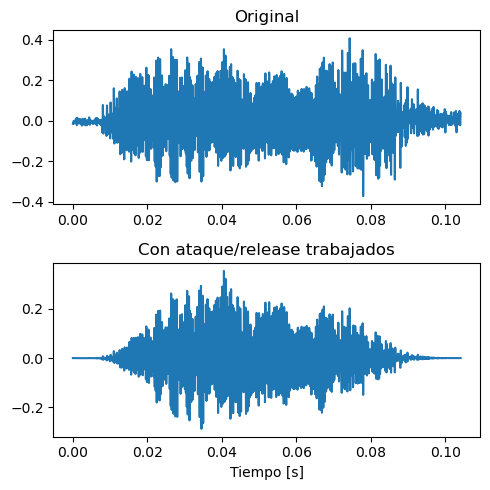

In [14]:
import numpy as np
import soundfile as sf
import os
import matplotlib.pyplot as plt

# Ruta del archivo de entrada
in_path = r"C:\Users\felic\OneDrive\Documentos\Proyectos doctorado\Proyectos doctorado\horneros\audios\audios_para_experimentos_2025\medio.wav"

# 1) Leer audio
x, sr = sf.read(in_path)
N = x.shape[0]

# ==== 2) ATAQUE y RELEASE con forma Hann (coseno) ====
attack_sec  = 0.04   # duración del ataque en segundos  (ajustá acá)
release_sec = 0.06   # duración del release en segundos (ajustá acá)

Na = max(2, int(attack_sec  * sr))   # muestras de ataque
Nr = max(2, int(release_sec * sr))   # muestras de release

w = np.ones(N)

n_a = np.arange(Na)
n_r = np.arange(Nr)

# Hann 0→1 y 1→0
fade_in  = 0.5 - 0.5 * np.cos(np.pi * n_a / (Na - 1))
fade_out = 0.5 - 0.5 * np.cos(np.pi * n_r / (Nr - 1))

# Opcional: cambiar curvatura (p>1 bordes más “afilados”, p<1 más suaves)
attack_sec  = 0.005   # 5 ms de ataque
release_sec = 0.005   # 5 ms de release
p_attack  = 1.0
p_release = 1.0

w[:Na]    = fade_in
w[-Nr:]   = fade_out[::-1]

# 3) Aplicar ventana
if x.ndim == 1:
    y = x * w
else:
    y = x * w[:, np.newaxis]

# 4) Guardar resultado
base, ext = os.path.splitext(in_path)
out_path = base + "_suavizado.wav"
sf.write(out_path, y, sr)

print("Salida:", out_path)

# 5) Graficar
t = np.arange(N) / sr

plt.figure(figsize=(5, 5))
plt.subplot(2, 1, 1)
plt.plot(t, x[:,0] if x.ndim>1 else x)
plt.title("Original")
plt.subplot(2, 1, 2)
plt.plot(t, y[:,0] if y.ndim>1 else y)
plt.title("Con ataque/release trabajados")
plt.xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

sf.write(r"C:\Users\felic\OneDrive\Documentos\Proyectos doctorado\Proyectos doctorado\horneros\audios\audios_para_experimentos_2025\medio_suavizado.wav", y, sr)


In [1]:
import numpy as np
import soundfile as sf
import os

# --------- PARÁMETROS ----------
silaba_path        = r"C:\Users\felic\OneDrive\Documentos\Proyectos doctorado\Proyectos doctorado\horneros\audios\audios_para_experimentos_2025\medio_suavizado.wav"
total_dur_sec      = 5.0   # duración total del estímulo (s)
onset_interval_sec = 0.15    # intervalo entre inicios de sílabas (s)
# -------------------------------

# Leer sílaba suavizada
syl, sr = sf.read(silaba_path)
Ns = syl.shape[0]
syl_dur = Ns / sr
print(f"Duración sílaba: {syl_dur:.3f} s")

# Preparar salida
step = int(round(onset_interval_sec * sr))    # muestras entre onsets
Ntot = int(round(total_dur_sec * sr))         # muestras totales

if syl.ndim == 1:
    out = np.zeros(Ntot, dtype=syl.dtype)
else:
    out = np.zeros((Ntot, syl.shape[1]), dtype=syl.dtype)

# Colocar copias de la sílaba
n = 0
while True:
    start = n * step
    if start >= Ntot:
        break
    end = start + Ns
    if end <= Ntot:
        out[start:end] += syl
    else:
        # última sílaba cortada al final
        L = Ntot - start
        if L <= 0:
            break
        out[start:Ntot] += syl[:L]
    n += 1

print(f"Se colocaron {n} sílabas.")

# Guardar archivo de salida
base, ext = os.path.splitext(silaba_path)
out_path = base + f"_loop_{int(total_dur_sec)}s.wav"
sf.write(out_path, out, sr)
print("Archivo guardado en:", out_path)


Duración sílaba: 0.104 s
Se colocaron 34 sílabas.
Archivo guardado en: C:\Users\felic\OneDrive\Documentos\Proyectos doctorado\Proyectos doctorado\horneros\audios\audios_para_experimentos_2025\medio_suavizado_loop_5s.wav
